In [69]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [70]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [71]:
def reconstruct_path(node: "Node") -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []
    while node is not None:
        path.append(node.state)
        node = node.parent
    path.reverse()
    return path


def reconstruct_actions(node: "Node") -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []
    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent
    actions.reverse()
    return actions


@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [72]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [73]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}
class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        return state == self.goal
        raise NotImplementedError("Complete GridProblem.is_goal")

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        # Return a list of legal action names.

         # Steps:
        # 1. Create an empty list called legal_actions.
        # 2. For each action in MOVES:
        #       a. Compute the neighbour cell.
        #       b. Check that it is in bounds.
        #       c. Check that it is free.
        #       d. If valid, add the action name to legal_actions. 
        legal_actions = []
        for action in MOVES:
             neighbour_cell = (state[0] + MOVES[action][0], state[1] + MOVES[action][1])
             if self.in_bounds(neighbour_cell)  and  self.is_free(neighbour_cell):
                 legal_actions.append(action)
  # 3. Return legal_actions.
        return legal_actions
         
        raise NotImplementedError("Complete GridProblem.actions")

    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:

        # Return the next state after applying action to state.
        #
        # Hint:
        # dr, dc = MOVES[action]
        # return (row + dr, col + dc)
        dr, dc = MOVES[action]
        row = state[0]
        col = state[1]
        return ( row + dr, col + dc)
    
        raise NotImplementedError("Complete GridProblem.result")

    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        # In this lab, each valid move has a cost of 1.
        # Return 1.

        return 1
        raise NotImplementedError("Complete GridProblem.action_cost")

In [74]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [75]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

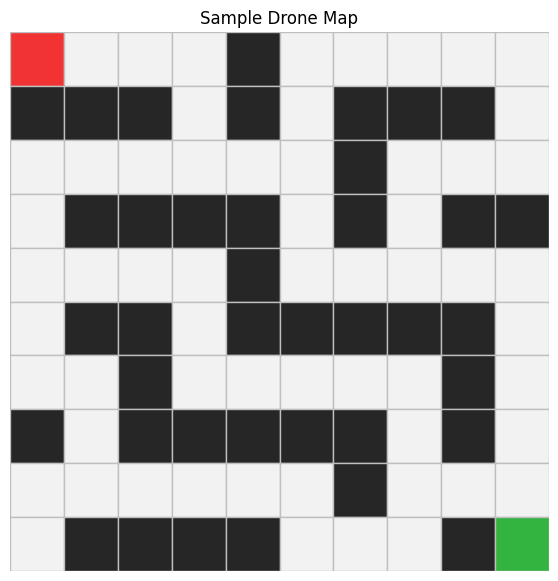

In [76]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )
    plt.show()
    
    
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [77]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        # Implement the AIMA-style EXPAND(problem, node).
        #
        # Pseudocode:
        # s <- node.STATE
        # for each action in problem.ACTIONS(s):
        #     s_prime <- problem.RESULT(s, action)
        #     cost <- node.PATH_COST + problem.ACTION_COST(s, action, s_prime)
        #     yield NODE(STATE=s_prime, PARENT=node, ACTION=action, PATH_COST=cost)
        
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s, action)
            cost = node.path_cost + problem.action_cost(s, action, s_prime)
            yield Node(s_prime,node,action,cost)


    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [78]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"
        
        node = Node(problem.initial_state())
        nodes_expanded = 0
        max_frontier_size = 1
        
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm=algorithm,
                status="success",
                solution=node,
                nodes_expanded=nodes_expanded,
                max_frontier_size=max_frontier_size,
                reached_count=1
            )
        
        frontier = deque([node]) # Store Node objects, not just states
        reached = {node.state}
        
        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1
            
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )
                
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
            
            
            max_frontier_size = max(max_frontier_size, len(frontier))
            
        return SearchResult(
            algorithm=algorithm,
            status="failure",
            solution=None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached)
        )
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        # raise NotImplementedError("Complete BreadthFirstSearch.search")

In [79]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        
        node = Node(problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(
            algorithm,'success',node
        )
        # 3. Use a Python list as the stack frontier.
        frontier = [node]
        nodes_expanded = 0
        max_frontier_size = 1
        # 4. Use a reached set.
       
        reached ={node.state}
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.

        while frontier :
            node = frontier.pop()
            nodes_expanded += 1

            children = list(self.expand(problem, node))
            for child in reversed(children):
                s = child.state
                
                if problem.is_goal(s):
                    return SearchResult(
                        algorithm=algorithm,
                        status="success",
                        solution=child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=max_frontier_size,
                        reached_count=len(reached)
                    )
                
                if s not in reached:
                    reached.add(s)
                    frontier.append(child)
                    
            max_frontier_size = max(max_frontier_size, len(frontier))

        return SearchResult(algorithm, "failure", None, nodes_expanded, max_frontier_size, len(reached))
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        raise NotImplementedError("Complete DepthFirstSearch.search")

In [80]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        
        if problem.is_goal(node.state):
            return node, 'success'
        elif node.depth >= limit:
            return None, "cutoff"
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occured = False

            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state):
                    continue
                
                metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size + 1)
                
                result, status = self._recursive_dls(problem, child, limit, metrics, current_stack_size + 1)
                
                if status == "success":
                    return result, status
                elif status == "cutoff":
                    cutoff_occured = True

            if cutoff_occured:
                return None, "cutoff"  
            else:
                return None, "failure"

In [81]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        iteration_log = []
        dls = DepthLimitedSearch()
        total_nodes_expanded = 0
        global_max_stack_size = 0  
        any_cutoff = False         

        for limit in range(max_depth + 1):
            result = dls.search(problem, limit)
            status = result.status
            total_nodes_expanded += result.nodes_expanded
            
            global_max_stack_size = max(global_max_stack_size, result.max_frontier_size)
            iteration_log.append([limit, result.status])

            if status == "success":
                result.algorithm = algorithm
                result.nodes_expanded = total_nodes_expanded
                result.max_frontier_size = global_max_stack_size
                return result
            
            if status == "cutoff":
                any_cutoff = True
            elif status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=global_max_stack_size,
                    limit=limit
                )

        final_status = "cutoff" if any_cutoff else "failure"
        return SearchResult(
            algorithm=algorithm,
            status=final_status,
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=global_max_stack_size,
            limit=max_depth
        )

In [82]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)





,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,5,52
1,DFS,success,NaN,26.0,26.0,37,4,39
2,DLS,cutoff,10.0,NaN,NaN,16,11,0
3,IDS,success,18.0,18.0,18.0,356,19,0


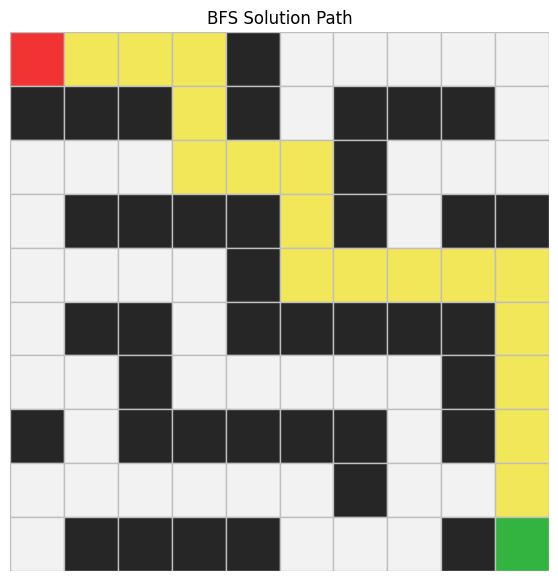

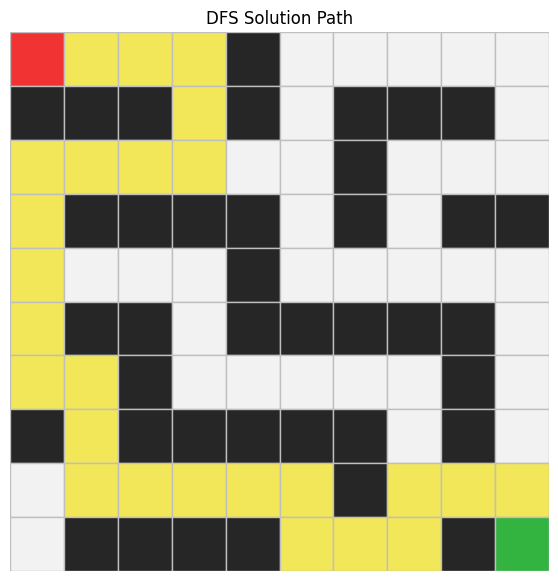

In [83]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

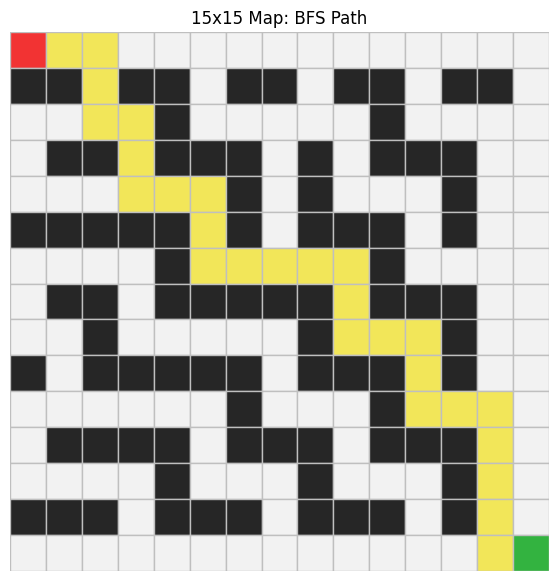

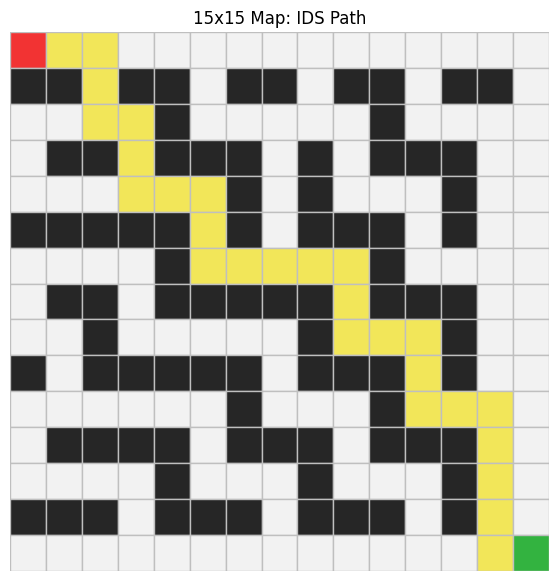

In [84]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0],
    [1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
 ]

custom_start_1 = (0, 0)
custom_goal_1 = (14, 14)

# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

plot_path(custom_grid_1, custom_start_1, custom_goal_1, path=custom_results_1[0].path, title="15x15 Map: BFS Path")
plot_path(custom_grid_1, custom_start_1, custom_goal_1, path=custom_results_1[3].path, title="15x15 Map: IDS Path")

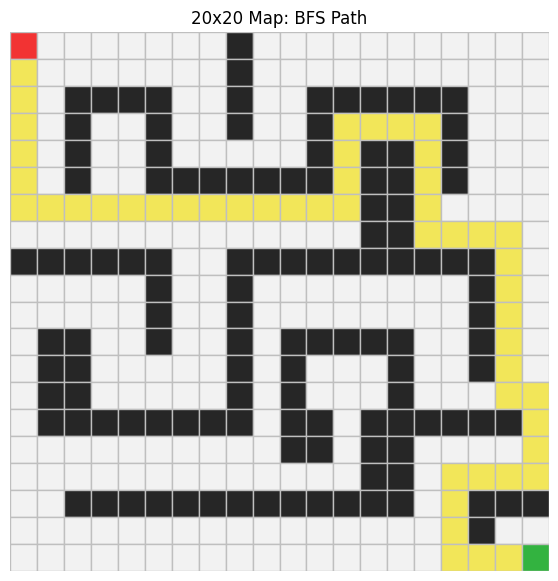

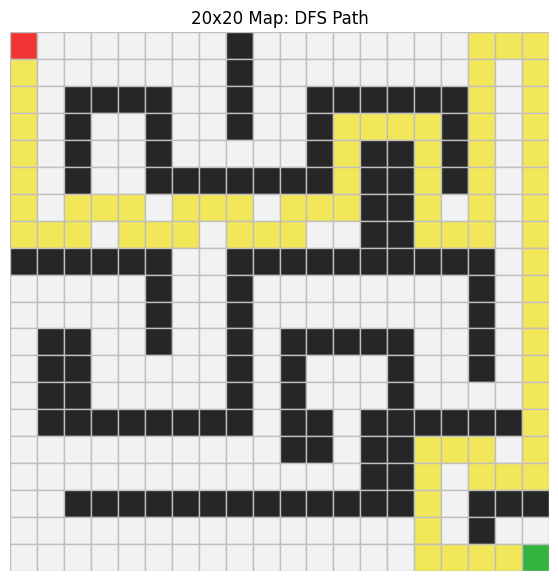

In [85]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0],
    [0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0],
    [0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0],
    [0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
]


custom_start_2 = (0, 0)
custom_goal_2 = (19, 19)
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)

# Example after completing:
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=10), # Higher limit so DLS doesn't trigger a cutoff too early
    ids.search(custom_problem_2, max_depth=30),
]
show_results(custom_results_2)
plot_path(custom_grid_2, custom_start_2, custom_goal_2, path=custom_results_2[0].path, title="20x20 Map: BFS Path")
plot_path(custom_grid_2, custom_start_2, custom_goal_2, path=custom_results_2[1].path, title="20x20 Map: DFS Path")

15.1

1.In this lab,A state is a specific configuration or position in the grid that represents the current situation of the agent (e.g., the drone's location). 

2.An action is a move that the agent can take to transition from one state to another (e.g., moving up, down, left, or right).

3.The result function takes a state and an action as input and returns the new state that results from applying that action to the given state.


3.Separating the problem definition from the search algorithm is useful because it supports reusability where the same search algorithm can be applied to different problem definitions and it promotes clarity making the code more organized and easier to understand.  




15.2
1.BFS uses a FIFO (First-In-First-Out) queue to ensure that it explores all nodes at the present depth level before moving on to nodes at the next depth level. 

2.Since all edges (or moves) have the same cost BFS finds the shortest path in terms of the number of steps on an unweighted grid because it explores all possible paths level by level.

3.In BFS, the reached set plays a crucial role in preventing the algorithm from revisiting states that have already been explored. 


15.3
1.DFS uses a stack because it explores as far down a branch of the search tree as possible before backtracking by using a Last-In-First-Out data structure, which allows the algorithm to keep track of the most recently discovered nodes and explore them first.

2.DFS is not guaranteed to find the shortest path. It may find a solution that is deeper in the search tree, which could be longer than a solution found by BFS. 

3.DFS can use less memory than BFS in scenarios where the search tree is very deep but has a limited branching factor. 

4.If the search space is very deep or infinite, DFS may go down a long path without finding a solution, and  might shorter paths that lead to the optimal solution.


15.4
1.When the depth limit is too small in Depth-Limited Search , the algorithm may not be able to reach the goal state if it is located deeper in the search tree than the specified limit. 

2.The DLS retiuns  a "cutoff" status instead of finding a solution, indicating that the search was terminated due to reaching the depth limit without finding a goal.

3.DLS varies from DFS because it imposes a limit on the depth of the search tree. In  DFS, the algorithm explores  far down a branch as possible before backtracking whilst DLS limits the depth of exploration to a specified maximum depth. 

4 We use path-cycle checking in Depth-Limited Search  to prevent the algorithm from revisiting states that are already on the current path from the root node to the current node. 


15.5
1.IDS repeats DLS  with increasing limits because it combines the benefits of both depth-first and breadth-first search.  This approach allows IDS to find the optimal solution without consuming excessive memory, as it only needs to store a single path from the root to the current node at any given time.

2.IDS  can be complete even though DLS with a small limit is not because IDS systematically increases the depth limit with each iteration.

3.IDS  uses less memory than BFS  because of the way it explores the search space.

4.The cost of repeatedly searching from the root in search algorithms like Iterative Deepening Search (IDS) can be significant, especially in terms of time complexity. In IDS, the algorithm performs a series of depth-limited searches, starting from the root node and increasing the depth limit with each iteration.


15.6
1.In a real drone application, several factors can make one route safer or more practical than another,routes with less obstacles such as buildings, trees, and power lines are safer. A route with fewer obstacles reduces the risk of collisions and  Routes that are less affected by adverse weather conditions.

2.If all moves are equally costly and the primary concern is to find the solution with the fewest number of moves, I would choose the Breadth-First Search (BFS) algorithm.

3.If I want to limit how deep the drone is allowed to search, I would choose the Depth-Limited Search (DLS) algorithm.

4.The grid model used in this exercise has several limitations compared to real drone navigation , The grid model represents the environment as a discrete set of cells, while real-world environments are continuous. Drones can move in any direction and at varying speeds, not just in fixed increments. Obstacles in the grid are represented as binary values (0 for free, 1 for blocked), which does not capture the complexity of real-world obstacles. In reality, obstacles can have varying shapes, sizes, and properties that affect navigation.